In [1]:
# Import packages
import pandas as pd
import numpy as np

import ossify as osy
from standard_transform.datasets import v1dd_ds

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [11]:
import sys
from os.path import join as pjoin
from typing import Optional, Union
utils_path = "/root/capsule/code/utils"
sys.path.insert(0, utils_path)

import itertools

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import tqdm
from connects_common_connectivity.io import DatasetReader, read_synapse_table
from matplotlib import pyplot as plt
from scipy import spatial, stats
from scipy.sparse import csr_array

from paths import resolve_data_root, resolve_dataset_dir

mat_version = 1196
data_root = resolve_data_root(f"v1dd_{mat_version}_ccm")

# The EM side: cells, cell types and synapses, in Common Connectivity format
ccm_dir = resolve_dataset_dir(f"v1dd_{mat_version}_ccm", root=data_root)

project_id = "v1dd"
synapse_dataset_id = f"v1dd_{mat_version}_em"
synapse_feature_matrix_id = f"v1dd_{mat_version}_synapse_features"
axon_dataset_id = f"v1dd_{mat_version}_proofread_axons"
dendrite_dataset_id = f"v1dd_{mat_version}_proofread_dendrites"

# The two-photon side: its own dataset on CodeOcean, but it sits next to the older feather
# tables if you downloaded those together. Accept either.
functional_dir = resolve_dataset_dir(
    f"v1dd_{mat_version}_coreg_functional_correlation",
    f"v1dd_{mat_version}",
    root=data_root,
)

print(f"ccm_dir        {ccm_dir}")
print(f"functional_dir {functional_dir}")

ccm_dir        /root/capsule/data/v1dd_1196_ccm
functional_dir /root/capsule/data/v1dd_1196_coreg_functional_correlation


In [12]:
from caveclient import CAVEclient

# Token Generation and Setup
CAVEclient.setup_token("https://global.em.brain.allentech.org")

# Initialize CAVEclient
client = CAVEclient(datastack_name="v1dd_public")


(node:72302) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)


Visit https://global.em.brain.allentech.org/sticky_auth/settings/tokens and copy an existing token or create a new one.
All datastacks are configured to use this server address.
You will not need to specify a server address when initializing a client for configured datastacks in the future.
Setup complete!


In [ ]:
# thalamic_proofreading
# thalamic_table = client.info.get_datastack_info()['thalamic_proofreading']
df_thalamic=client.materialize.query_table('thalamic_proofreading')

In [ ]:
df_thalamic

In [ ]:
# Initialize the Common Connectivity dataset reader
reader = DatasetReader(ccm_dir)
reader.display_dataset_names()  # see available cohorts

In [ ]:
# Load the features and cell type table of cells with axon and dendrite proofreading
proofread_axons = reader.read_dataset(axon_dataset_id)
proofread_dendrites = reader.read_dataset(dendrite_dataset_id)

# Extract the root IDs of the proofread dendrites and axons
dendrite_proof_root_ids = proofread_dendrites["dataitem_id"].cast(pl.UInt64).to_numpy()
axon_proof_root_ids = proofread_axons["dataitem_id"].cast(pl.UInt64).to_numpy()

print(
    f"There are {len(dendrite_proof_root_ids)} cells with acceptable dendrites, and {len(axon_proof_root_ids)} cells with axon proofreading"
)
proofread_axons.head(3)

In [ ]:
thal = client.materialize.query_table("thalamic_proofreading")

thal_ids = (
    thal["pt_root_id"]
    .dropna()
    .unique()
)

thal_ids = [int(x) for x in thal_ids]

print(thal_ids)

In [ ]:
len(thal_ids)

In [ ]:
thal_syn_1 = client.materialize.synapse_query(
    pre_ids=thal_ids[:50],
    desired_resolution=[1, 1, 1]
)

thal_syn_2 = client.materialize.synapse_query(
    pre_ids=thal_ids[50:],
    desired_resolution=[1, 1, 1]
)

thal_syn = pd.concat([thal_syn_1, thal_syn_2], ignore_index=True)

In [ ]:
thal_syn.to_csv('thal_syn.csv', index=False)

In [2]:
thal_syn = pd.read_csv('thal_syn.csv')

In [3]:
thal_syn.head()

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position
0,282681478,2021-11-19 01:35:28.272045+00:00,NaN,True,2902.0,88397162936966358,864691132647486796,88397162936965005,864691132832053252,[665158 653081 511605],[665332 652761 511380],[665051 653062 511560]
1,324977225,2021-11-18 22:16:58.141699+00:00,NaN,True,739.0,89662287497449724,864691132804540262,89591918753323750,864691132612319611,[709739 598771 182340],[709341 598781 182655],[709555 598810 182430]
2,404535272,2021-11-18 22:03:58.345906+00:00,NaN,True,750.0,93321462999446267,864691132647486796,93321462999447466,864691131718083940,[840058 599654 438525],[839622 599624 438525],[839816 599692 438435]
3,417826507,2021-11-19 02:10:08.767039+00:00,NaN,True,1808.0,93532774786769330,864691132843175686,93532774786771710,864691132612319611,[846732 606385 243180],[847130 606638 243405],[846926 606531 243270]
4,295785734,2021-11-18 22:51:18.353664+00:00,NaN,True,2390.0,88465400438245810,864691132629122108,88535769182411361,864691132022324186,[669610 575520 205425],[670105 575520 205740],[669911 575491 205650]


In [4]:
print("thal axons:", thal_syn["pre_pt_root_id"].nunique())
print("post root IDs:", thal_syn["post_pt_root_id"].nunique())
print("synapses:", len(thal_syn))

thal axons: 97
post root IDs: 321532
synapses: 463661


In [5]:
thal_conn = (
    thal_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .agg(
        n_synapses=("id", "count"),
        total_synapse_size=("size", "sum"),
        mean_synapse_size=("size", "mean"),
    )
    .reset_index()
)

thal_conn.head()

,pre_pt_root_id,post_pt_root_id,n_synapses,total_synapse_size,mean_synapse_size
0,864691132537321562,864691128466949053,1,1360.0,1360.0
1,864691132537321562,864691128474129087,1,997.0,997.0
2,864691132537321562,864691128484359153,1,350.0,350.0
3,864691132537321562,864691128485206136,1,714.0,714.0
4,864691132537321562,864691128485640407,1,885.0,885.0


In [6]:
thal_input_per_cell = (
    thal_syn
    .groupby("post_pt_root_id")
    .agg(
        n_synapses=("id", "count"),
        n_thalamic_axons=("pre_pt_root_id", "nunique"),
        total_synapse_size=("size", "sum"),
        mean_synapse_size=("size", "mean"),
    )
    .reset_index()
)

thal_input_per_cell.head()

,post_pt_root_id,n_synapses,n_thalamic_axons,total_synapse_size,mean_synapse_size
0,0,6,5,9991.0,1665.166667
1,864691128456072427,1,1,339.0,339.000000
2,864691128456090329,1,1,1987.0,1987.000000
3,864691128456790098,1,1,431.0,431.000000
4,864691128457382381,1,1,579.0,579.000000


In [7]:
conn_count = thal_conn.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

conn_count.shape

(97, 321532)

In [8]:
conn_count

post_pt_root_id,0,864691128456072427,864691128456090329,864691128456790098,864691128457382381,864691128457503409,864691128457504177,864691128457574221,864691128457842865,864691128457973116,...,864691133314147664,864691133314166096,864691133314168144,864691133314185552,864691133314195280,864691133314201424,864691133314206544,864691133314222928,864691133314231632,864691133314233424
pre_pt_root_id,,,,,,,,,,,,,,,,,,,,,
864691132537321562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132549572162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132572564252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132582739474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
864691132582742802,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864691132970239597,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
864691133001102261,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
864691133050913636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
neurons = client.materialize.query_table(
    "neurons_soma_model", #A subset of nucleus detections predicted be neurons from a model trained on soma and nucleus features.
)

neuron_ids = set(
    neurons["pt_root_id"]
    .dropna()
    .astype("uint64")
)

thal_syn_neurons = thal_syn[
    thal_syn["post_pt_root_id"].isin(neuron_ids)
].copy()

print(
    "all post roots:",
    thal_syn["post_pt_root_id"].nunique()
)

print(
    "postsynaptic neurons:",
    thal_syn_neurons["post_pt_root_id"].nunique()
)

all post roots: 321532
postsynaptic neurons: 27436


In [14]:
thal_conn_neurons = (
    thal_syn_neurons
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .agg(
        n_synapses=("id", "count"),
        total_synapse_size=("size", "sum")
    )
    .reset_index()
)

conn_count = thal_conn_neurons.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

print(conn_count.shape)

(97, 27436)


In [31]:
conn_size = thal_conn_neurons.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="total_synapse_size"
).fillna(0)

print(conn_size.shape)

(97, 27436)


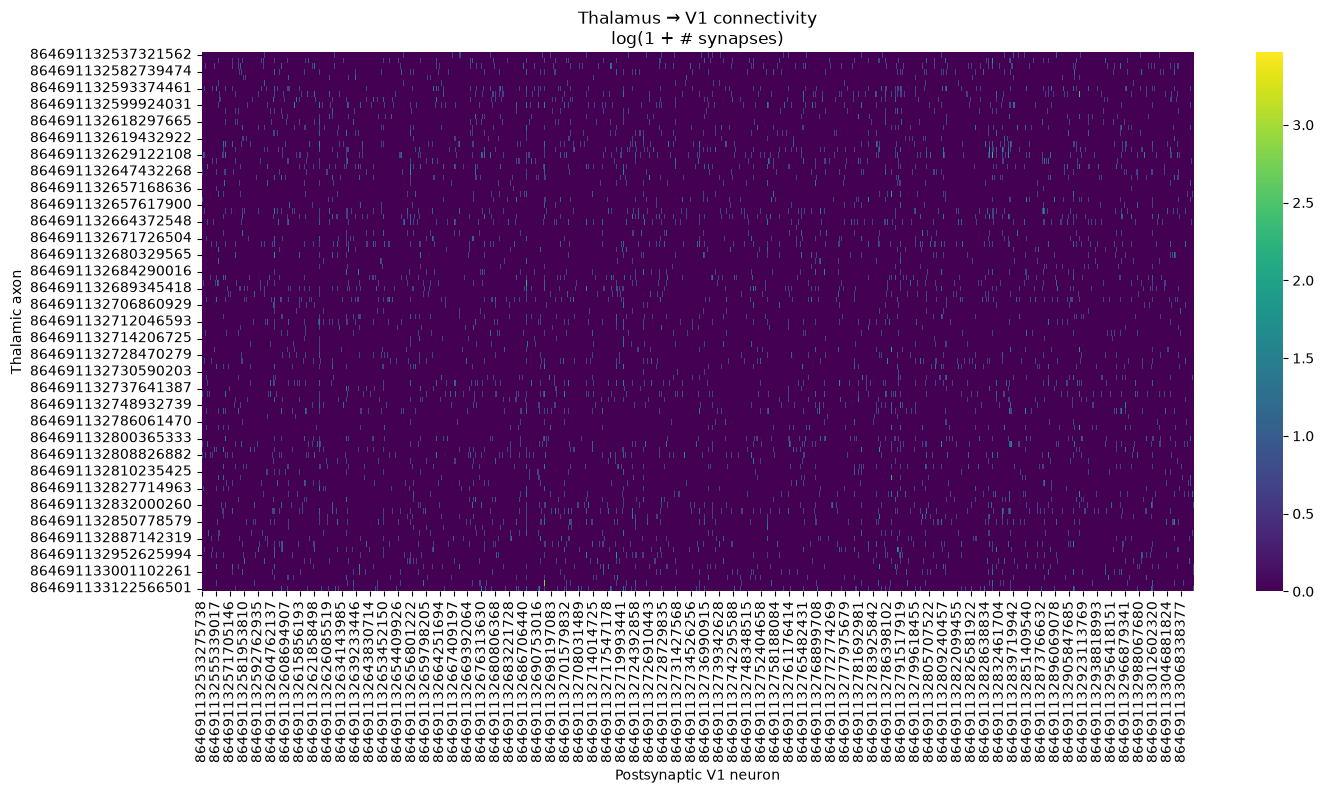

In [15]:
plt.figure(figsize=(16, 7))

sns.heatmap(
    np.log1p(conn_count),
    cmap="viridis",
)

plt.xlabel("Postsynaptic V1 neuron")
plt.ylabel("Thalamic axon")
plt.title("Thalamus → V1 connectivity\nlog(1 + # synapses)")

plt.show()

In [19]:
cell_types = client.materialize.query_table(
    "cell_type_multifeature_v1",
)

print(cell_types.columns)
cell_types[[
    "pt_root_id",
    "classification_system",
    "cell_type"
]].head()

Index(['id', 'created', 'valid', 'target_id', 'classification_system',
       'cell_type', 'id_ref', 'created_ref', 'valid_ref', 'volume',
       'pt_supervoxel_id', 'pt_root_id', 'pt_position', 'bb_start_position',
       'bb_end_position'],
      dtype='object')


,pt_root_id,classification_system,cell_type
0,864691132654552792,excitatory,L3IT
1,864691132773514104,excitatory,L2IT
2,864691132777373560,excitatory,L4IT
3,864691132802050269,excitatory,L5IT
4,864691132752568948,excitatory,L6CT


In [21]:
meta = cell_types[
    ["pt_root_id", "classification_system", "cell_type"]
].copy()

meta = meta[
    meta["pt_root_id"].isin(conn_count.columns)
].copy()

print(len(meta))

meta["layer"] = meta["cell_type"].str.extract(r"^(L[1-6])")

20149


In [29]:
meta["cell_type"]

0        L3IT
1        L2IT
2        L4IT
7        L6CT
8        L6CT
         ... 
48062    L3IT
48066    L4IT
48067    L2IT
48069     PTC
48071    L4IT
Name: cell_type, Length: 20149, dtype: string

In [23]:
type_order = {
    "L2IT": 0,
    "L3IT": 1,
    "L4IT": 2,

    "L5IT": 3,
    "L5ET": 4,
    "L5NP": 5,

    "L6IT": 6,
    "L6CT": 7,
    "L6SP": 8,

    "PTC": 9,
    "DTC": 10,
    "STC": 11,
    "ITC": 12,
}

meta["type_order"] = meta["cell_type"].map(type_order)

In [24]:
meta_sorted = meta.sort_values(
    ["type_order", "pt_root_id"]
)

ordered_post_ids = meta_sorted["pt_root_id"].tolist()

conn_sorted = conn_count.loc[:, ordered_post_ids]

print(conn_sorted.shape)

(97, 20149)


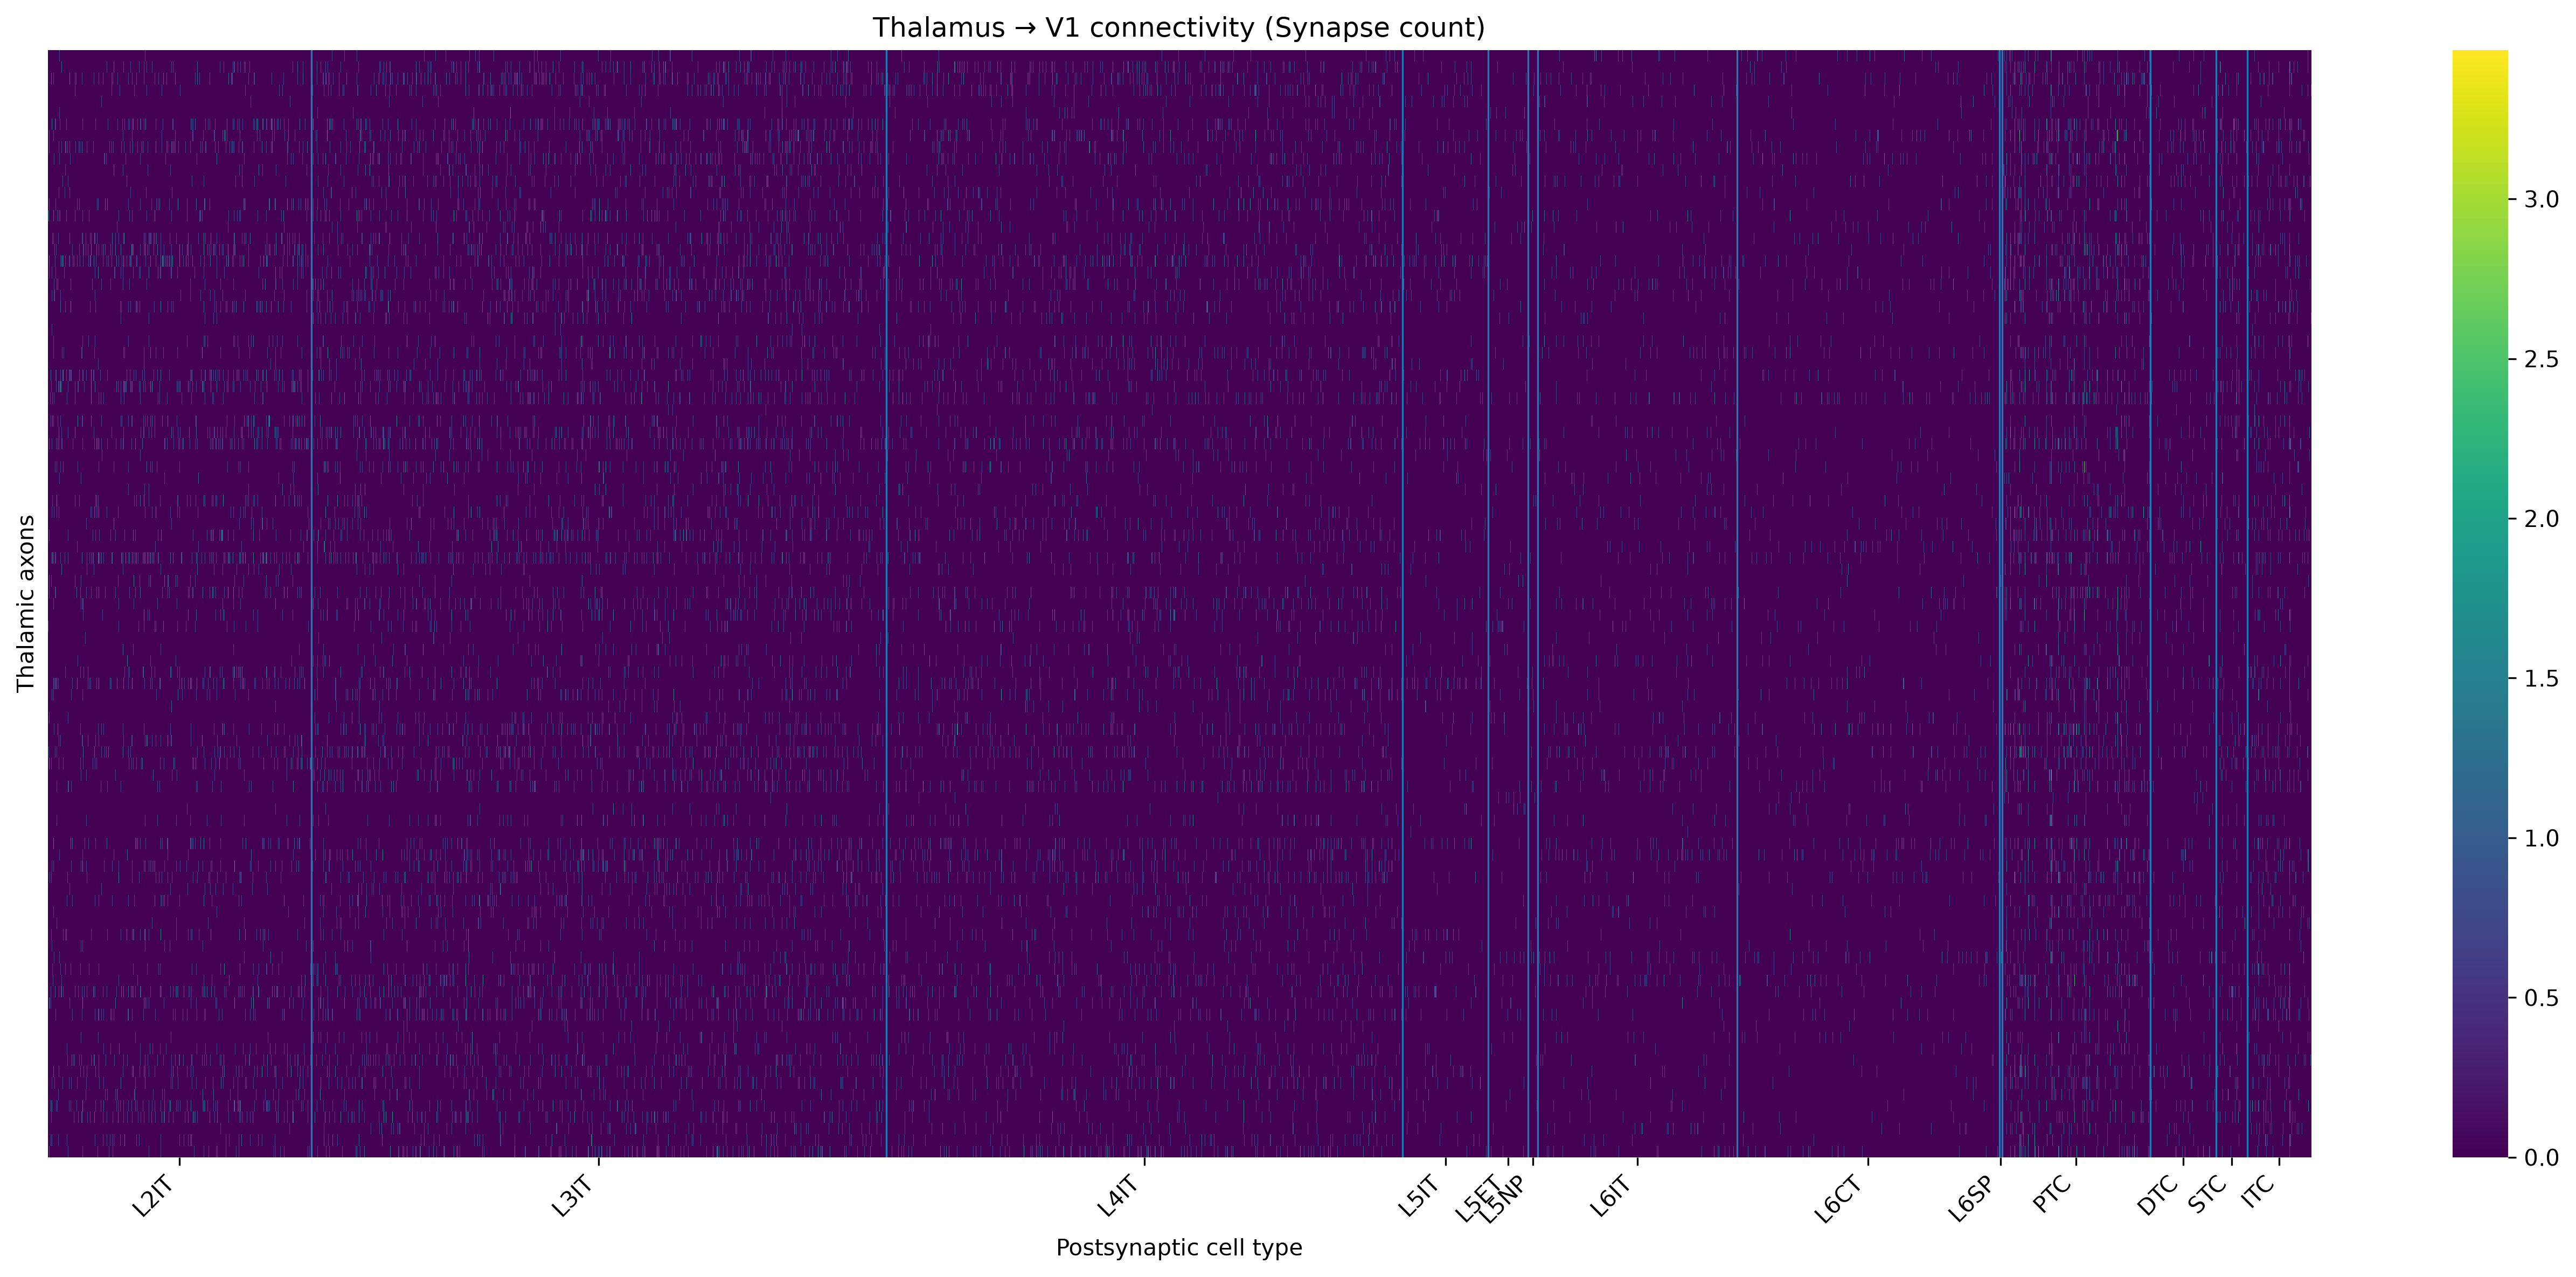

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

group_sizes = (
    meta_sorted
    .groupby("cell_type", sort=False)
    .size()
)

group_sizes

fig, ax = plt.subplots(figsize=(18, 8), dpi =300)

sns.heatmap(
    np.log1p(conn_sorted),
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

starts = np.r_[0, np.cumsum(group_sizes.values)[:-1]]
ends   = np.cumsum(group_sizes.values)

centers = (starts + ends) / 2

for x in ends[:-1]:
    ax.axvline(x, linewidth=0.8)

ax.set_xticks(centers)
ax.set_xticklabels(
    group_sizes.index,
    rotation=45,
    ha="right"
)

ax.set_xlabel("Postsynaptic cell type")
ax.set_ylabel("Thalamic axons")
ax.set_title("Thalamus → V1 connectivity (Synapse count)")

plt.tight_layout()
plt.show()

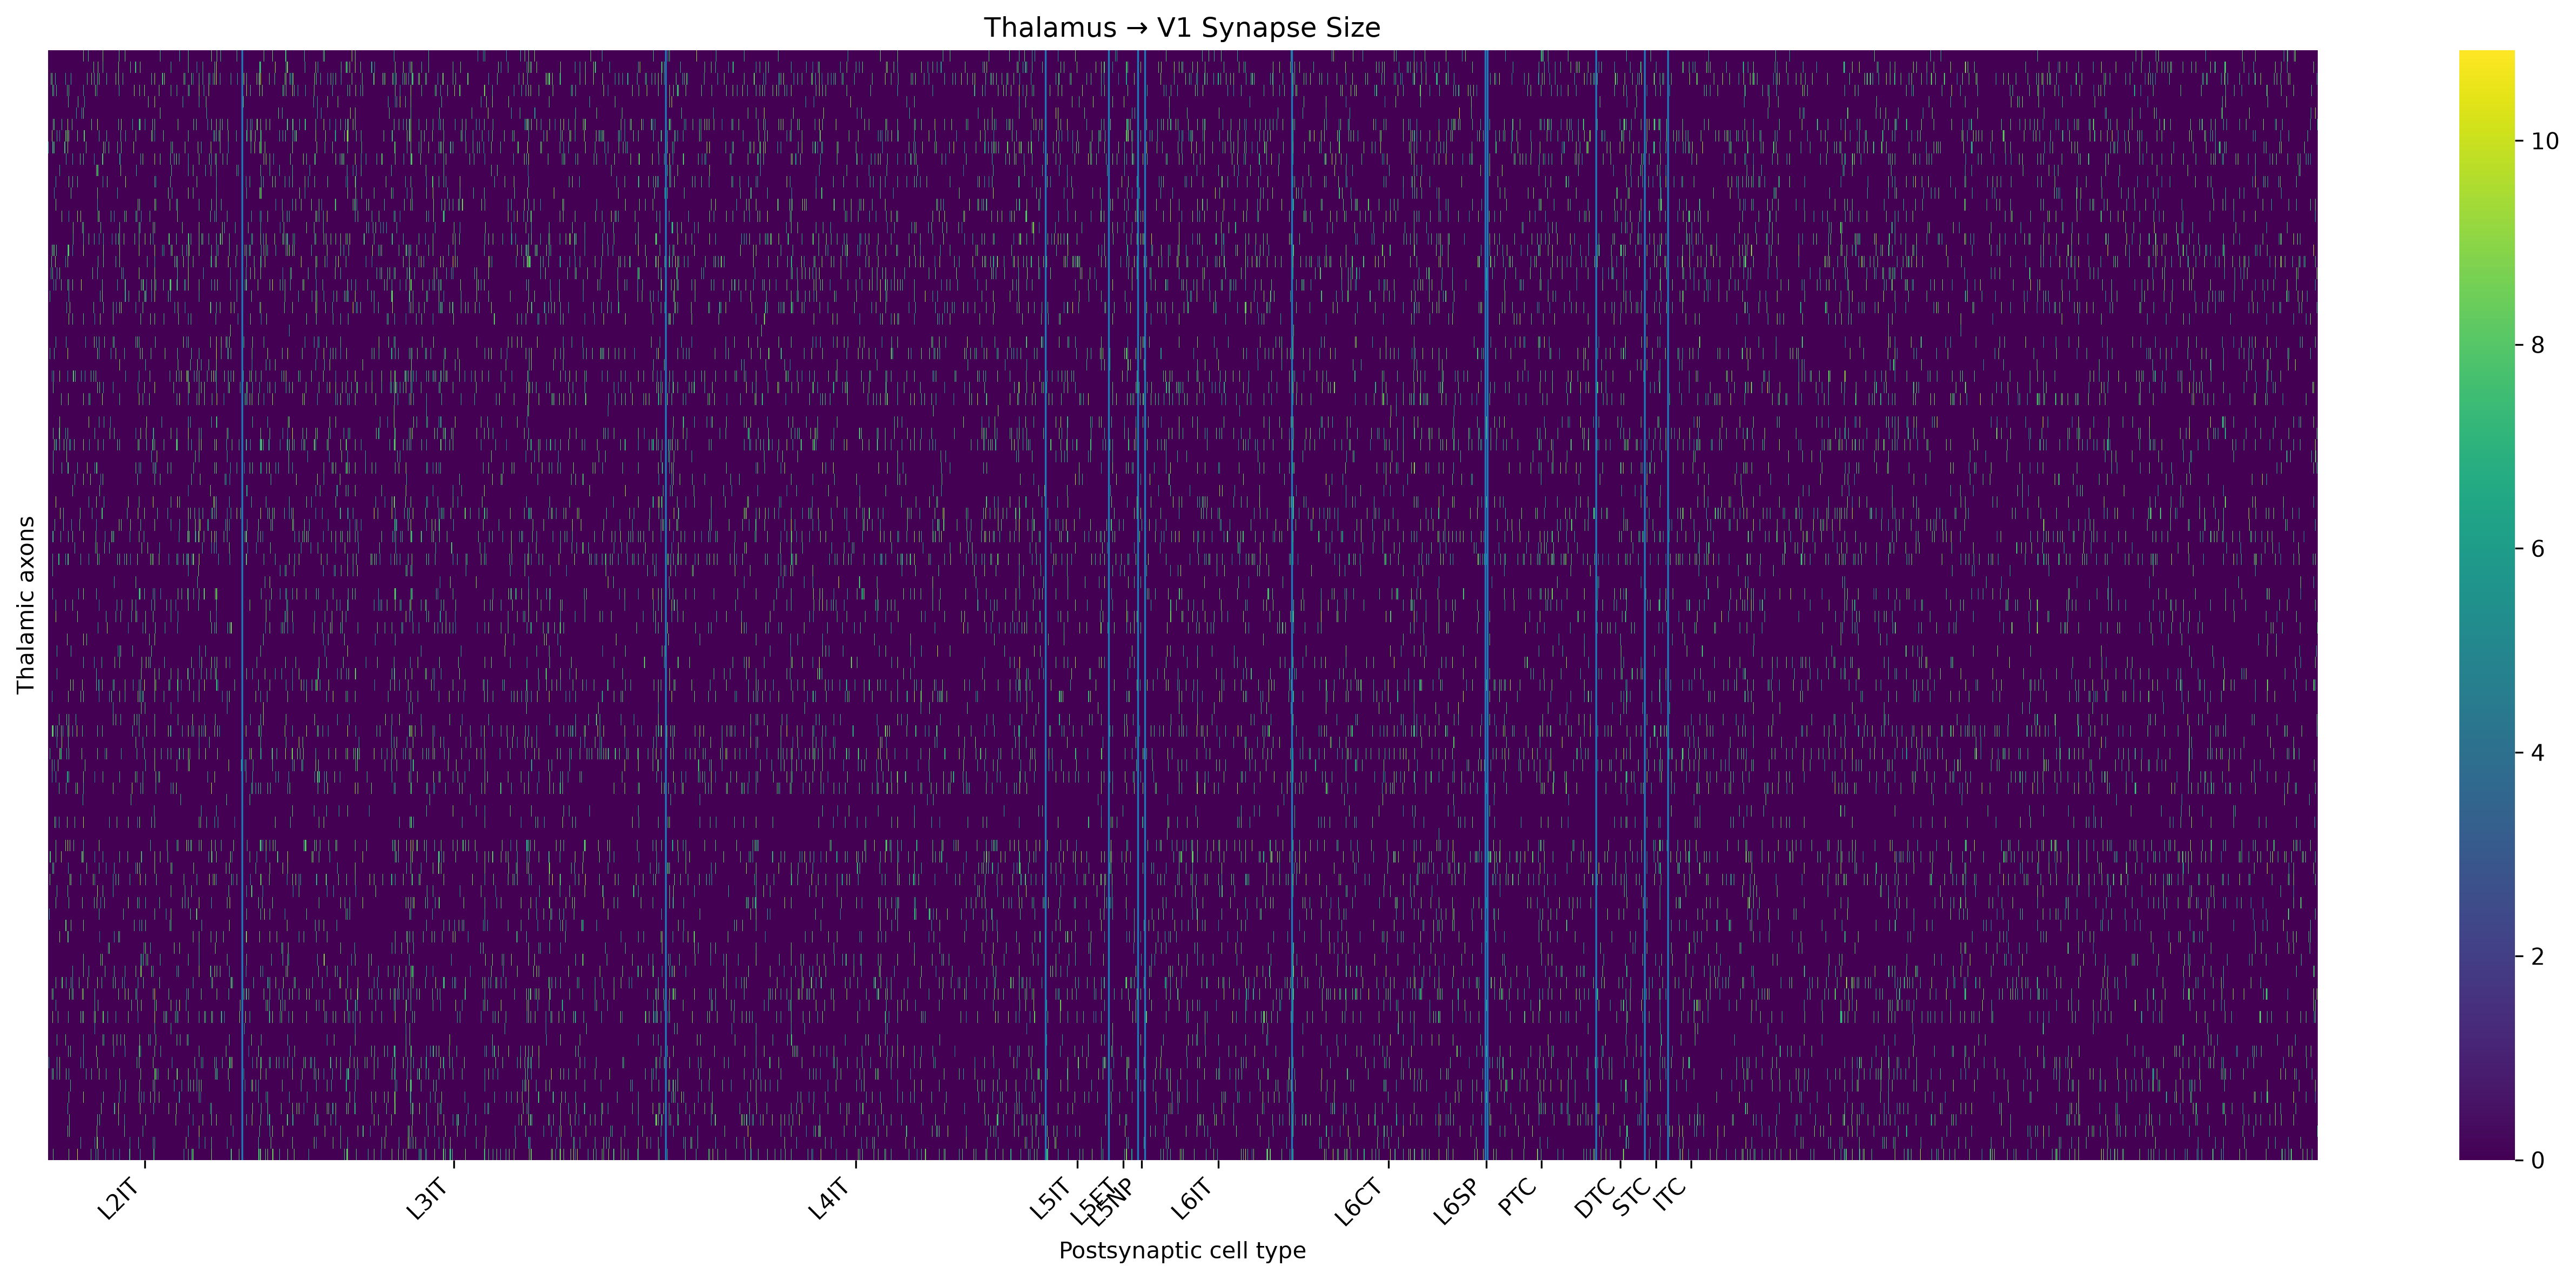

In [32]:
fig, ax = plt.subplots(figsize=(18, 8), dpi =300)

sns.heatmap(
    np.log1p(conn_size),
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

starts = np.r_[0, np.cumsum(group_sizes.values)[:-1]]
ends   = np.cumsum(group_sizes.values)

centers = (starts + ends) / 2

for x in ends[:-1]:
    ax.axvline(x, linewidth=0.8)

ax.set_xticks(centers)
ax.set_xticklabels(
    group_sizes.index,
    rotation=45,
    ha="right"
)

ax.set_xlabel("Postsynaptic cell type")
ax.set_ylabel("Thalamic axons")
ax.set_title("Thalamus → V1 Synapse Size")

plt.tight_layout()
plt.show()